# 🌊 Notebook 13: Full Pipeline — EDA, CEDA & Maximum Strategy
**Eksperimen 16 | Target: submission_13.csv**

## Fondasi & Inovasi
Notebook ini merangkum **seluruh alur data science** secara komprehensif sambil membangun model terkuat kita sejauh ini. Dibuat pada hari ke-8 kompetisi dengan prioritas: **tembus Top 10 dari rank 50-an**.

Fondasi: Eksperimen 14 (CV 1.6449, Public 1.632 — Best Score Datashine)

### Inovasi Baru di Eksperimen 16:
1. **Cumulative Future Rain Signal** — Total curah hujan yang terakumulasi sejak awal periode test (Sep 19, 2025) untuk setiap titik prediksi. Berbeda dari rolling window (melihat ke belakang), ini melihat *"seberapa basah musim hujan ini sejauh ini?"*
2. **Cross-Station Spatial Influence** — TMA tetangga tertimbang jarak (dipertahankan dari Exp 15)
3. **Extended Rolling Windows** — 14 hari dan 28 hari (dari Exp 15)
4. **Optuna 100 Trials** — Peningkatan dari 60 trials untuk tuning lebih akurat

## 0. Setup & Konfigurasi

In [1]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
from sklearn.cluster import KMeans
from sklearn.model_selection import TimeSeriesSplit
import optuna
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Gunakan style seaborn standar agar aman
sns.set_theme(style='whitegrid')

# Config
SEED          = 42
N_FOLDS       = 5
N_OPTUNA      = 100
EARLY_STOP    = 300
SCALE_KM      = 30.0   # radius pengaruh spasial
OUTPUT_CSV    = '../submissions/submission_13.csv'
TRAIN_PATH    = '../data/raw/train.csv'
TEST_PATH     = '../data/raw/test.csv'
ENV_PATH      = '../data/raw/data_pendukung/data_lingkungan.csv'
COORDS_PATH   = '../data/raw/data_pendukung/koordinat_pos.csv'

## 1. Pemuatan Data

In [2]:
train    = pd.read_csv(TRAIN_PATH)
test     = pd.read_csv(TEST_PATH)
env_data = pd.read_csv(ENV_PATH)
coords   = pd.read_csv(COORDS_PATH)

train['datetime']    = pd.to_datetime(train['datetime'])
test['datetime']     = pd.to_datetime(test['id'].str[:19])
test['nama_pos']     = test['id'].str[22:]
env_data['datetime'] = pd.to_datetime(env_data['datetime'])
overall_cutoff       = train['datetime'].max()

print('=== Info Dataset ===')
print(f'Train  : {train.shape[0]:,} baris | {train["datetime"].min().date()} s.d. {train["datetime"].max().date()}')
print(f'Test   : {test.shape[0]:,} baris  | {test["datetime"].min().date()} s.d. {test["datetime"].max().date()}')
print(f'Env    : {env_data.shape[0]:,} baris | {env_data["datetime"].min().date()} s.d. {env_data["datetime"].max().date()}')
print(f'Stasiun: {train["nama_pos"].nunique()} pos')
print(f'Cutoff : {overall_cutoff}')
print(f'\nEnv covers test period? {env_data["datetime"].max() >= test["datetime"].max()}')
print(f'\nKolom Env:')
print(env_data.columns.tolist())

=== Info Dataset ===
Train  : 84,396 baris | 2023-01-01 s.d. 2025-09-18
Test   : 21,780 baris  | 2025-09-19 s.d. 2026-05-18
Env    : 888,480 baris | 2023-01-01 s.d. 2026-05-18
Stasiun: 30 pos
Cutoff : 2025-09-18 18:00:00

Env covers test period? True

Kolom Env:
['datetime', 'nama_pos', 'rainfall_mm', 'humidity_pct', 'wind_direction_deg', 'dew_point_c', 'cloud_cover_pct', 'temperature_c', 'wind_speed_kmh', 'rainfall_openmeteo_mm', 'rainfall_max_24h_mm', 'solar_radiation_mj_m2', 'soil_moisture_0_7cm', 'soil_moisture_7_28cm', 'soil_moisture_28_100cm', 'soil_moisture_100_255cm', 'surface_pressure_hpa', 'pressure_msl_hpa', 'built_surface_m2', 'landcover_class', 'landcover_name', 'rmm1', 'rmm2', 'mjo_phase', 'mjo_amplitude', 'mjo_active', 'nino_34']


## 2. EDA — Eksploratory Data Analysis
### 2.1 Distribusi Target (TMA)

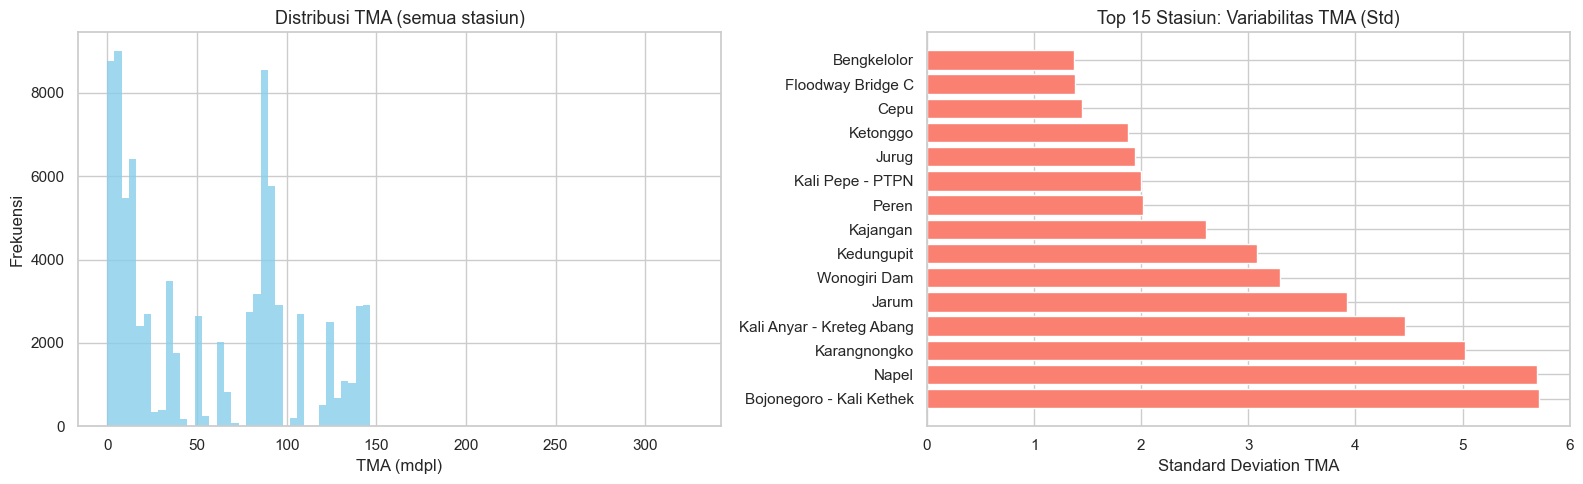


Top 10 Stasiun dengan Variabilitas Tertinggi:
                              mean    std      min      max
nama_pos                                                   
Bojonegoro - Kali Kethek    9.0550 5.7180   0.0000 225.1300
Napel                      34.2110 5.6920  30.8900 325.8300
Karangnongko               22.6870 5.0200  19.8050 177.0000
Kali Anyar - Kreteg Abang  86.4610 4.4640  84.4440 323.2070
Jarum                      90.7210 3.9180  89.2900 250.1400
Wonogiri Dam              132.3400 3.3000 125.5400 137.3570
Kedungupit                 64.8650 3.0820  62.1280 207.7360
Kajangan                   51.0440 2.6090  49.1760 172.7700
Peren                      91.3050 2.0160  90.1080 170.1000
Kali Pepe - PTPN           82.5470 2.0030   0.0000 138.0700

Global TMA: Mean=56.483, Std=46.766, Skew=0.343


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribusi global
axes[0].hist(train['tma_mdpl'].dropna(), bins=80, color='skyblue', alpha=0.8, edgecolor='none')
axes[0].set_title('Distribusi TMA (semua stasiun)', fontsize=13)
axes[0].set_xlabel('TMA (mdpl)'); axes[0].set_ylabel('Frekuensi')

# Statistik per stasiun
station_stats = train.groupby('nama_pos')['tma_mdpl'].agg(['mean','std','min','max']).sort_values('std', ascending=False)
axes[1].barh(station_stats.index[:15], station_stats['std'][:15], color='salmon')
axes[1].set_title('Top 15 Stasiun: Variabilitas TMA (Std)', fontsize=13)
axes[1].set_xlabel('Standard Deviation TMA')
plt.tight_layout()
plt.show()

print('\nTop 10 Stasiun dengan Variabilitas Tertinggi:')
print(station_stats.head(10).round(3).to_string())
print(f'\nGlobal TMA: Mean={train["tma_mdpl"].mean():.3f}, Std={train["tma_mdpl"].std():.3f}, Skew={train["tma_mdpl"].skew():.3f}')

### 2.2 Pola Temporal

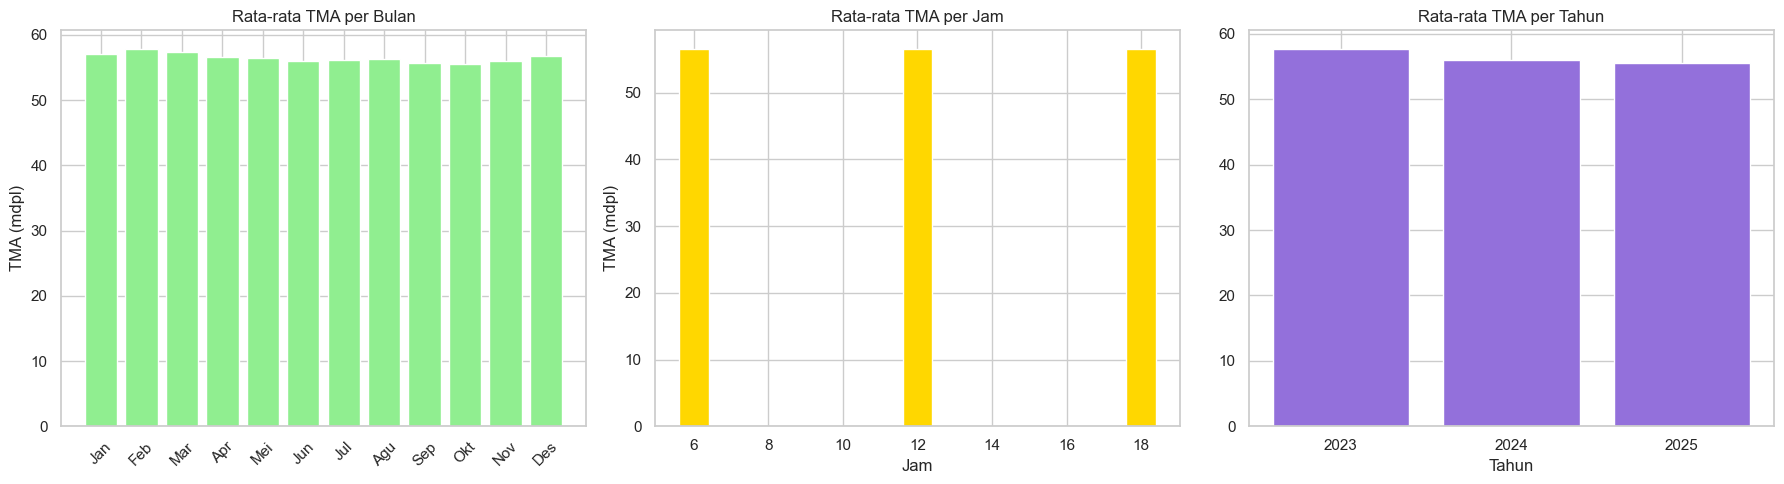

TMA per Bulan:
   Jan: 57.141
   Feb: 57.804
   Mar: 57.319
   Apr: 56.589
   Mei: 56.428
   Jun: 55.980
   Jul: 56.174
   Agu: 56.236
   Sep: 55.677
   Okt: 55.577
   Nov: 56.061
   Des: 56.781


In [4]:
train['month'] = train['datetime'].dt.month
train['hour']  = train['datetime'].dt.hour
train['year']  = train['datetime'].dt.year

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Per bulan
monthly = train.groupby('month')['tma_mdpl'].mean()
bulan_label = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']
axes[0].bar(range(1,13), monthly.values, color='lightgreen')
axes[0].set_xticks(range(1,13)); axes[0].set_xticklabels(bulan_label, rotation=45)
axes[0].set_title('Rata-rata TMA per Bulan'); axes[0].set_ylabel('TMA (mdpl)')

# Per jam
hourly = train.groupby('hour')['tma_mdpl'].mean()
axes[1].bar(hourly.index, hourly.values, color='gold')
axes[1].set_title('Rata-rata TMA per Jam'); axes[1].set_xlabel('Jam'); axes[1].set_ylabel('TMA (mdpl)')

# Per tahun
yearly = train.groupby('year')['tma_mdpl'].mean()
axes[2].bar(yearly.index.astype(str), yearly.values, color='mediumpurple')
axes[2].set_title('Rata-rata TMA per Tahun'); axes[2].set_xlabel('Tahun')

plt.tight_layout()
plt.show()

print('TMA per Bulan:')
for m, v in monthly.items():
    print(f'  {bulan_label[m-1]:>4}: {v:.3f}')

### 2.3 Analisis Missing & Kualitas Data

In [5]:
print('=== Missing Values Train ===')
print(train.isnull().sum())
print(f'\n=== Missing Values Env Data ===')
miss_env = env_data.isnull().mean() * 100
print(miss_env[miss_env > 0].sort_values(ascending=False).to_string())

# Gap deteksi di TMA
print(f'\n=== Gap Deteksi Antar Pengukuran ===')
for pos in train['nama_pos'].unique()[:5]:
    pos_df = train[train['nama_pos']==pos].sort_values('datetime')
    gaps = pos_df['datetime'].diff().dt.total_seconds().div(3600).dropna()
    max_gap = gaps.max()
    if max_gap > 6:
        print(f'  {pos}: max gap = {max_gap:.0f} jam')
    else:
        print(f'  {pos}: konsisten 6 jam')

=== Missing Values Train ===
datetime    0
nama_pos    0
tma_mdpl    0
month       0
hour        0
year        0
dtype: int64

=== Missing Values Env Data ===
nino_34                   1.4587
soil_moisture_0_7cm       0.0810
soil_moisture_28_100cm    0.0810
soil_moisture_7_28cm      0.0810
soil_moisture_100_255cm   0.0810
surface_pressure_hpa      0.0810
rmm1                      0.0810
pressure_msl_hpa          0.0810
rmm2                      0.0810
mjo_phase                 0.0810
mjo_amplitude             0.0810
mjo_active                0.0810

=== Gap Deteksi Antar Pengukuran ===
  Arjowinangun - Pacitan: max gap = 594 jam
  Babat: max gap = 612 jam
  Badegan: max gap = 612 jam
  Bengkelolor: max gap = 612 jam
  Boboh Kali Lamong: max gap = 600 jam


## 3. CEDA — Contextual EDA
### 3.1 Korelasi Fitur Lingkungan vs TMA

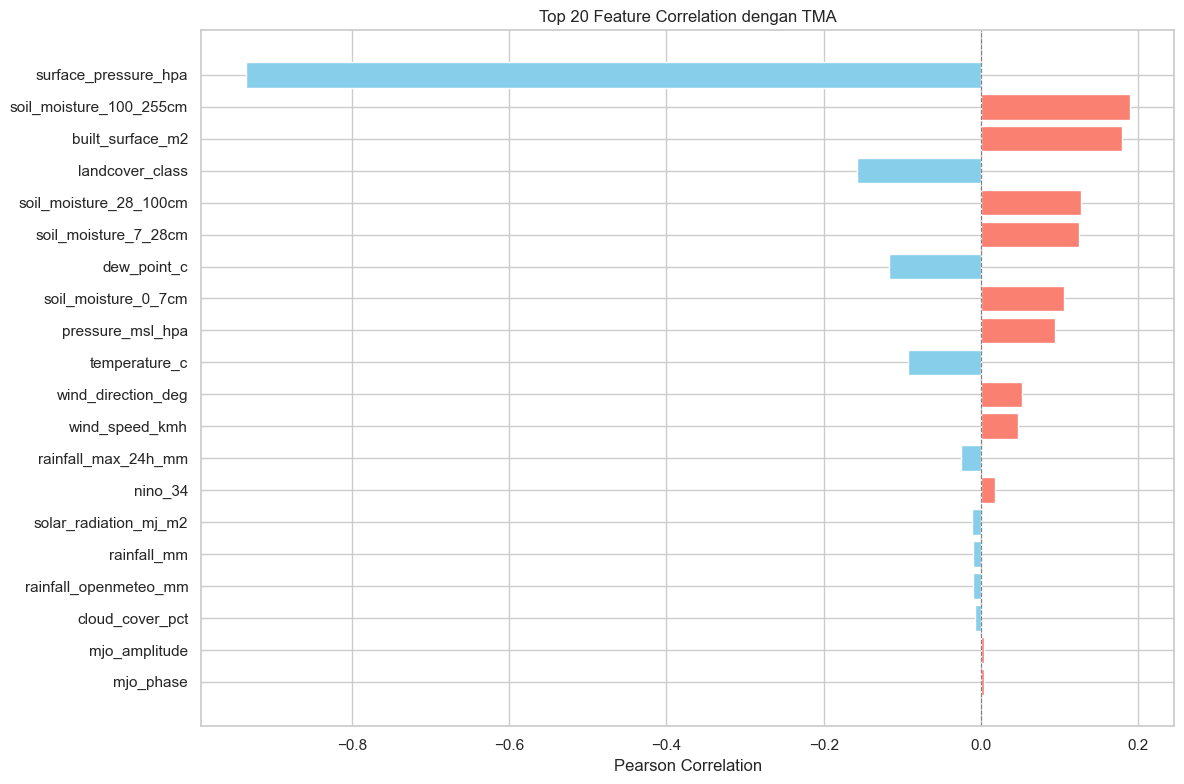

Top 10 fitur berkorelasi:
  -0.9352  surface_pressure_hpa
  +0.1894  soil_moisture_100_255cm
  +0.1793  built_surface_m2
  -0.1573  landcover_class
  +0.1269  soil_moisture_28_100cm
  +0.1245  soil_moisture_7_28cm
  -0.1169  dew_point_c
  +0.1063  soil_moisture_0_7cm
  +0.0938  pressure_msl_hpa
  -0.0925  temperature_c


In [6]:
# Agregasi env 6h terlebih dahulu
env_sort = env_data.sort_values(['nama_pos','datetime'])
macro_cols   = ['nino_34','mjo_phase','mjo_amplitude','mjo_active','rmm1','rmm2']
dynamic_cols = ['surface_pressure_hpa','pressure_msl_hpa','soil_moisture_0_7cm',
                'soil_moisture_7_28cm','soil_moisture_28_100cm','soil_moisture_100_255cm']
for c in macro_cols:
    env_sort[c] = env_sort.groupby('nama_pos')[c].ffill().bfill()
for c in dynamic_cols:
    env_sort[c] = env_sort.groupby('nama_pos')[c].apply(
        lambda x: x.interpolate(method='linear').bfill().ffill()
    ).reset_index(level=0, drop=True)

agg_funcs = {col:'mean' for col in env_sort.columns if col not in ['nama_pos','landcover_name','datetime']}
agg_funcs['rainfall_mm']='sum'; agg_funcs['rainfall_openmeteo_mm']='sum'; agg_funcs['rainfall_max_24h_mm']='max'
env_6h = env_sort.set_index('datetime').groupby(
    ['nama_pos', pd.Grouper(freq='6h', label='right', closed='right')]
).agg(agg_funcs).reset_index()

# Merge dengan train
merged = pd.merge(train, env_6h, on=['datetime','nama_pos'], how='left')
num_cols = merged.select_dtypes(include=np.number).columns.tolist()
num_cols = [c for c in num_cols if c not in ['tma_mdpl','month','hour','year']]

corrs = {}
for c in num_cols:
    if merged[c].std() > 0 and merged[c].notnull().sum() > 100:
        corrs[c] = merged[['tma_mdpl',c]].corr().iloc[0,1]
        
corrs_sorted = dict(sorted(corrs.items(), key=lambda x: abs(x[1]), reverse=True))

plt.figure(figsize=(12,8))
top20 = list(corrs_sorted.items())[:20]
names, vals = zip(*top20)
colors = ['salmon' if v > 0 else 'skyblue' for v in vals]
plt.barh(list(names)[::-1], list(vals)[::-1], color=colors[::-1])
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title('Top 20 Feature Correlation dengan TMA')
plt.xlabel('Pearson Correlation')
plt.tight_layout(); plt.show()

print('Top 10 fitur berkorelasi:')
for k,v in list(corrs_sorted.items())[:10]:
    print(f'  {v:+.4f}  {k}')

### 3.2 Lag Analysis: Berapa jam setelah hujan, TMA naik?

Cross-Correlation Rainfall -> TMA (lag dalam step 6 jam):


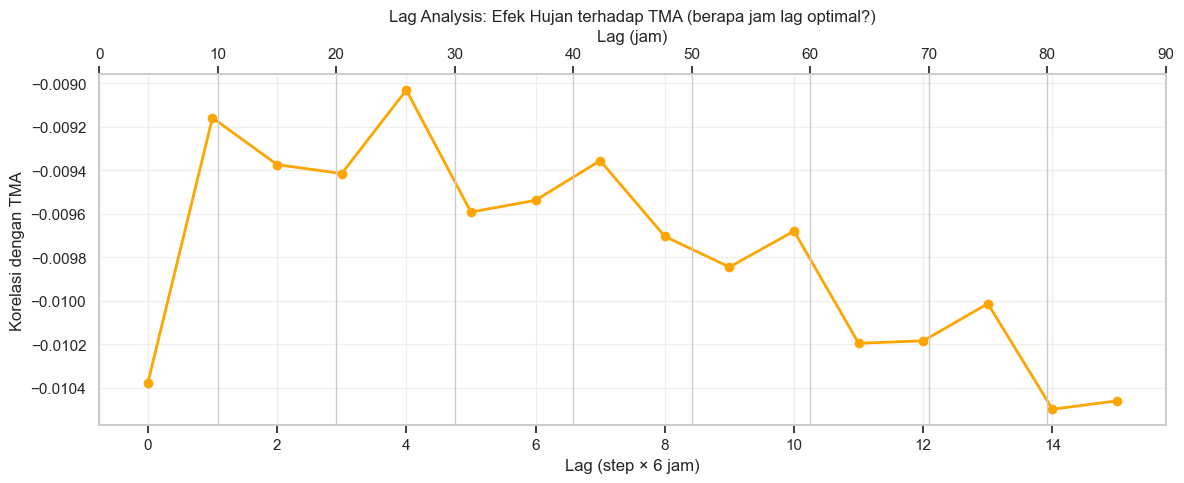


Rolling Window Accumulation vs TMA:
  Rolling   24h: -0.0164
  Rolling    3d: -0.0207
  Rolling    7d: -0.0242
  Rolling   14d: -0.0274
  Rolling   30d: -0.0307


In [7]:
# Rolling correlation dengan berbagai lag
print('Cross-Correlation Rainfall -> TMA (lag dalam step 6 jam):')
lag_corrs = {}
for lag in range(0, 16):
    merged[f'rain_lag{lag}'] = merged.groupby('nama_pos')['rainfall_mm'].shift(lag)
    corr = merged[['tma_mdpl', f'rain_lag{lag}']].corr().iloc[0,1]
    lag_corrs[lag] = corr

plt.figure(figsize=(12,5))
plt.plot(list(lag_corrs.keys()), list(lag_corrs.values()), 'o-', color='orange', linewidth=2)
plt.xlabel('Lag (step × 6 jam)'); plt.ylabel('Korelasi dengan TMA')
plt.title('Lag Analysis: Efek Hujan terhadap TMA (berapa jam lag optimal?)')
plt.grid(True, alpha=0.3)
ax2 = plt.gca().twiny()
ax2.set_xlim(0, 90); ax2.set_xlabel('Lag (jam)')
plt.tight_layout(); plt.show()

print('\nRolling Window Accumulation vs TMA:')
for label, w in [('24h',4),('3d',12),('7d',28),('14d',56),('30d',120)]:
    merged[f'roll_{label}'] = merged.groupby('nama_pos')['rainfall_mm'].transform(
        lambda x: x.rolling(w, min_periods=1).sum())
    corr = merged[['tma_mdpl', f'roll_{label}']].corr().iloc[0,1]
    print(f'  Rolling {label:>5}: {corr:.4f}')

### 3.3 Analisis Cuaca di Periode Test (Okt 2025 — Mei 2026)

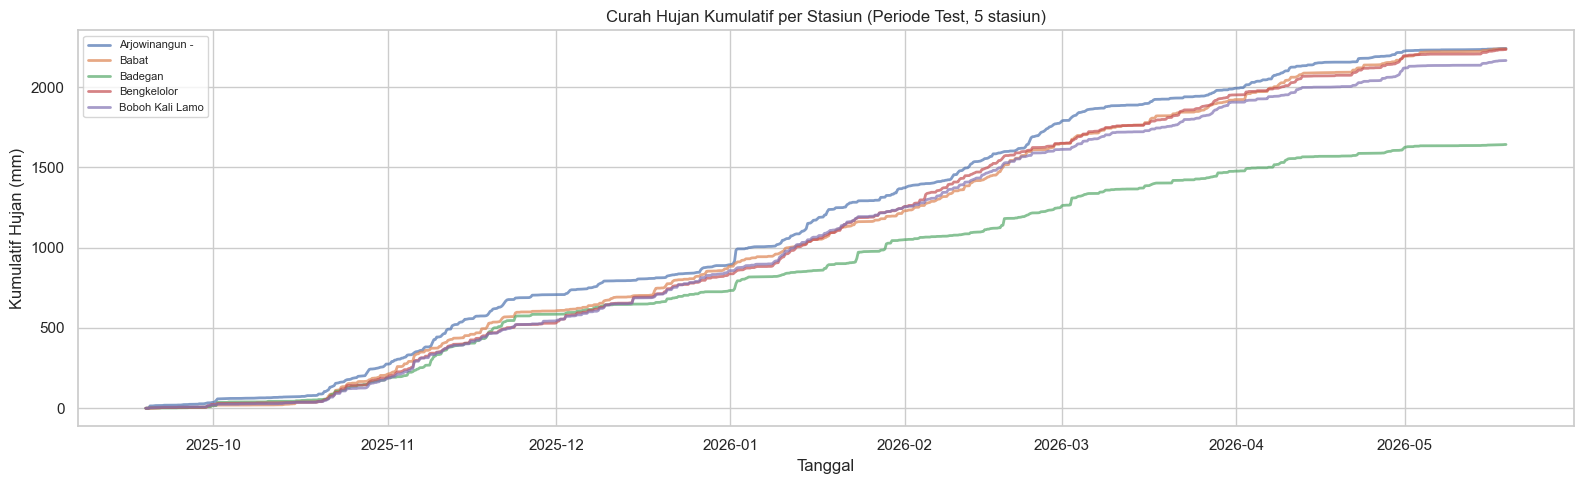

Rata-rata hujan per bulan di periode test:
   Jan: 11443.2 mm/bulan
   Feb: 10559.3 mm/bulan
   Mar: 7700.0 mm/bulan
   Apr: 7245.3 mm/bulan
   Mei: 1354.9 mm/bulan
   Sep: 953.6 mm/bulan
   Okt: 6733.0 mm/bulan
   Nov: 11040.3 mm/bulan
   Des: 6923.1 mm/bulan

Total hujan maks per stasiun sepanjang test: 2453 mm


In [8]:
env_test = env_6h[env_6h['datetime'] > overall_cutoff].copy()
env_test = env_test.sort_values(['nama_pos','datetime'])

# Curah hujan kumulatif sejak cutoff
env_test['rain_cum'] = env_test.groupby('nama_pos')['rainfall_mm'].cumsum()

env_test['month'] = env_test['datetime'].dt.month
env_test['year']  = env_test['datetime'].dt.year

plt.figure(figsize=(16,5))
for pos in env_test['nama_pos'].unique()[:5]:
    sub = env_test[env_test['nama_pos']==pos]
    plt.plot(sub['datetime'], sub['rain_cum'], alpha=0.7, linewidth=2, label=pos[:15])
plt.title('Curah Hujan Kumulatif per Stasiun (Periode Test, 5 stasiun)')
plt.xlabel('Tanggal'); plt.ylabel('Kumulatif Hujan (mm)')
plt.legend(loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

monthly_test = env_test.groupby(['year','month'])['rainfall_mm'].sum().groupby('month').mean()
print('Rata-rata hujan per bulan di periode test:')
for m,v in monthly_test.items():
    print(f'  {bulan_label[m-1]:>4}: {v:.1f} mm/bulan')
    
print(f'\nTotal hujan maks per stasiun sepanjang test: {env_test.groupby("nama_pos")["rain_cum"].max().max():.0f} mm')

### 3.4 Cross-Station TMA Correlation (Potensi Spatial Features)

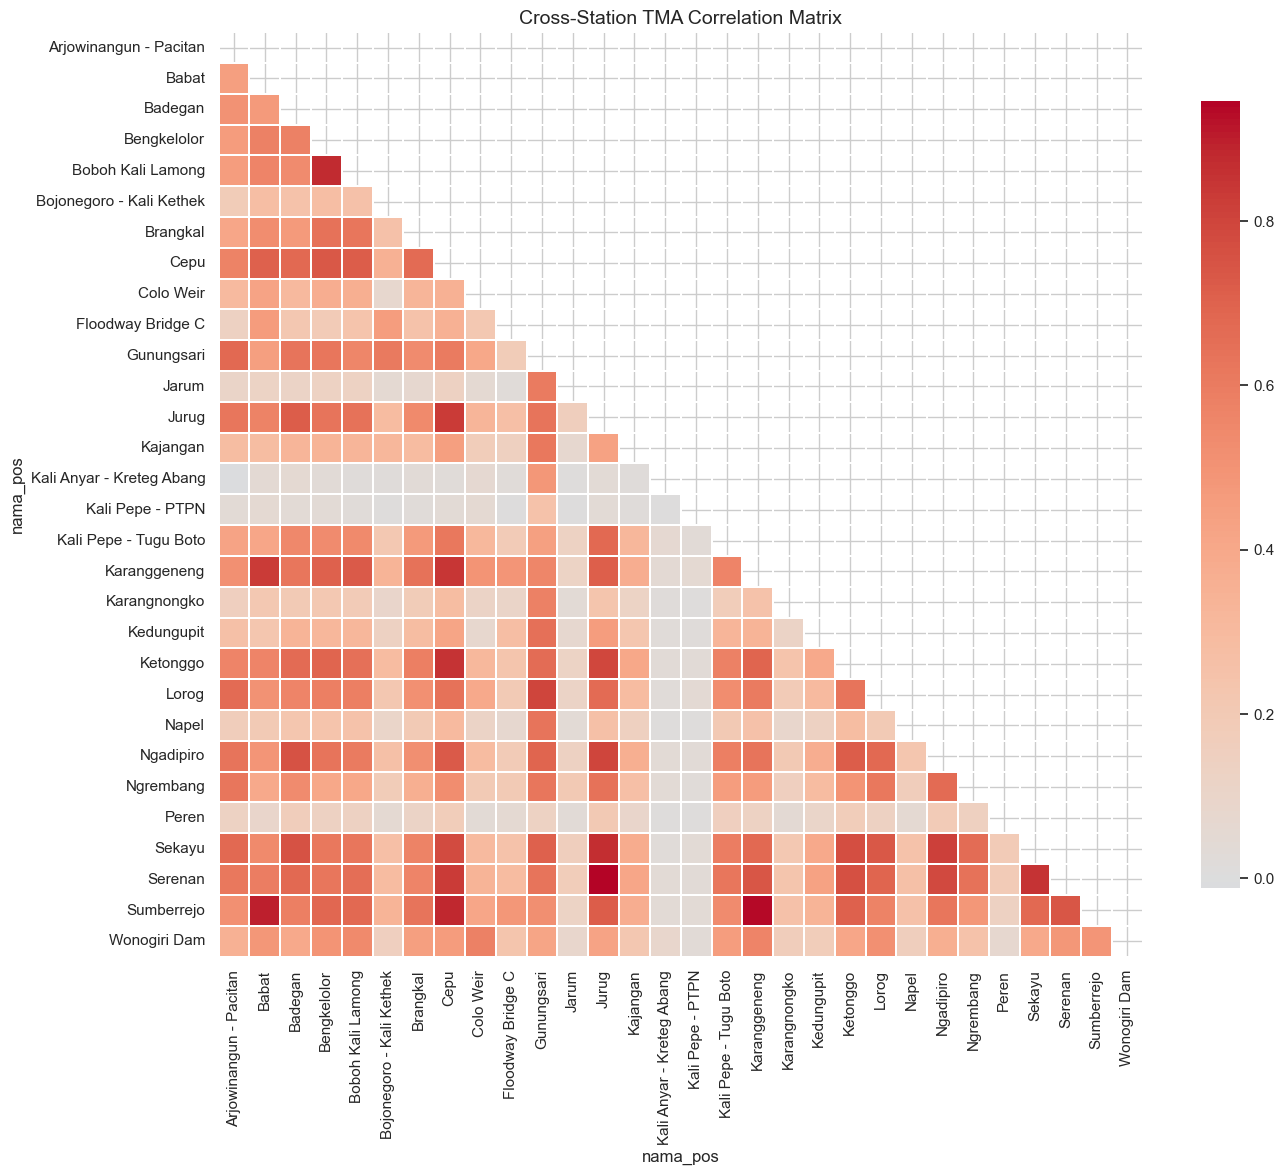

Rata-rata korelasi antar stasiun: 0.359
Pasangan dengan korelasi > 0.7: 37
Pasangan dengan korelasi < 0.1: 79

5 Pasangan berkorelasi TINGGI:
  Jurug                <-> Serenan             : 0.946
  Karanggeneng         <-> Sumberrejo          : 0.936
  Babat                <-> Sumberrejo          : 0.895
  Cepu                 <-> Sumberrejo          : 0.880
  Bengkelolor          <-> Boboh Kali Lamong   : 0.874


In [9]:
pivot = train.pivot_table(index='datetime', columns='nama_pos', values='tma_mdpl')
corr_matrix = pivot.corr()

plt.figure(figsize=(14,12))
mask = np.zeros_like(corr_matrix); mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            square=True, linewidths=0.3, annot=False, fmt='.2f',
            cbar_kws={'shrink':0.8})
plt.title('Cross-Station TMA Correlation Matrix', fontsize=14)
plt.tight_layout(); plt.show()

mask2 = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
upper_vals = corr_matrix.where(mask2).stack()
print(f'Rata-rata korelasi antar stasiun: {upper_vals.mean():.3f}')
print(f'Pasangan dengan korelasi > 0.7: {(upper_vals > 0.7).sum()}')
print(f'Pasangan dengan korelasi < 0.1: {(upper_vals < 0.1).sum()}')
print('\n5 Pasangan berkorelasi TINGGI:')
for (a,b), v in upper_vals.nlargest(5).items():
    print(f'  {a[:20]:20s} <-> {b[:20]:20s}: {v:.3f}')

## 4. Preprocessing
### 4.1 Profil Stasiun & Anchor TMA

In [10]:
global_mean = train['tma_mdpl'].mean()
global_std  = train['tma_mdpl'].std()

station_profile = train.groupby('nama_pos')['tma_mdpl'].agg(
    tma_mean='mean', tma_std='std',
    tma_p25=lambda x: x.quantile(0.25),
    tma_p75=lambda x: x.quantile(0.75)
).reset_index()
station_profile['tma_std'] = station_profile['tma_std'].fillna(1.0)

train_sorted = train.sort_values(['nama_pos', 'datetime'])
anchor_offsets = {'0h':'0H','24h':'24H','72h':'72H','168h':'168H',
                  '336h':'336H','720h':'720H','1440h':'1440H'}

def get_tma_at(pos_df, target_dt):
    subset = pos_df[pos_df['datetime'] <= target_dt]
    return np.nan if subset.empty else subset.iloc[-1]['tma_mdpl']

def get_window_stats(pos_df, end_dt, days):
    start_dt = end_dt - pd.Timedelta(f'{days}D')
    subset = pos_df[(pos_df['datetime'] >= start_dt) & (pos_df['datetime'] <= end_dt)]['tma_mdpl']
    if len(subset) < 2: return np.nan, np.nan
    return subset.std(), np.polyfit(np.arange(len(subset)), subset.values, 1)[0]

anchor_records = []
for pos in train['nama_pos'].unique():
    pos_df = train_sorted[train_sorted['nama_pos'] == pos]
    row = {'nama_pos': pos}
    for label, offset in anchor_offsets.items():
        row[f'tma_anchor_{label}'] = get_tma_at(pos_df, overall_cutoff - pd.Timedelta(offset))
    vol7, trend7  = get_window_stats(pos_df, overall_cutoff, 7)
    vol30, trend30= get_window_stats(pos_df, overall_cutoff, 30)
    row.update({'tma_vol_7d':vol7,'tma_trend_7d':trend7,'tma_vol_30d':vol30,'tma_trend_30d':trend30})
    anchor_records.append(row)

anchor_df = pd.DataFrame(anchor_records)
station_profile = pd.merge(station_profile, anchor_df, on='nama_pos', how='left')
print('Station Profile (sample):')
print(station_profile[['nama_pos','tma_mean','tma_anchor_0h','tma_anchor_168h','tma_trend_7d']].head(8).to_string())

Station Profile (sample):
                   nama_pos  tma_mean  tma_anchor_0h  tma_anchor_168h  tma_trend_7d
0    Arjowinangun - Pacitan    1.1165         1.0000           0.7972        0.0052
1                     Babat    6.3059         5.7600           5.8100        0.0006
2                   Badegan  122.4020       121.9900         122.0200       -0.0015
3               Bengkelolor    9.8138         9.6100           9.3100        0.0082
4         Boboh Kali Lamong    4.1070         3.2000           3.0000        0.0035
5  Bojonegoro - Kali Kethek    9.0552         7.8000           7.6800        0.0016
6                  Brangkal   12.9501        12.8500          12.7300        0.0096
7                      Cepu   17.5339        16.5300          16.5300       -0.0158


### 4.2 Seasonal Historical TMA

In [11]:
seasonal_mean = train.groupby(['nama_pos','month'])['tma_mdpl'].mean().reset_index()
seasonal_mean.columns = ['nama_pos','month','tma_seasonal_hist_mean']
seasonal_std  = train.groupby(['nama_pos','month'])['tma_mdpl'].std().reset_index()
seasonal_std.columns  = ['nama_pos','month','tma_seasonal_hist_std']
seasonal_profile = pd.merge(seasonal_mean, seasonal_std, on=['nama_pos','month'])
print(f'Profil musiman: {seasonal_profile.shape[0]} baris (pos x bulan)')

Profil musiman: 360 baris (pos x bulan)


### 4.3 Cross-Station Spatial Influence

In [12]:
sp_coords = pd.merge(station_profile[['nama_pos']], coords, on='nama_pos', how='left')
lats = sp_coords['latitude'].values
lons = sp_coords['longitude'].values
n_st = len(lats)

def haversine_matrix(lats, lons):
    R = 6371.0
    lat_r = np.radians(lats[:,None] - lats[None,:])
    lon_r = np.radians(lons[:,None] - lons[None,:])
    a = (np.sin(lat_r/2)**2
         + np.cos(np.radians(lats[:,None]))*np.cos(np.radians(lats[None,:]))*np.sin(lon_r/2)**2)
    return 2*R*np.arcsin(np.sqrt(np.clip(a,0,1)))

D = haversine_matrix(lats, lons)
np.fill_diagonal(D, np.inf)
print(f'Jarak rata-rata antar stasiun: {D.min(axis=1).mean():.1f} km')

for label in ['0h','24h','72h','168h','336h']:
    anchor_vals = station_profile[f'tma_anchor_{label}'].values.astype(float)
    wmeans, mxnn3 = [], []
    for i in range(n_st):
        weights = np.exp(-D[i]/SCALE_KM)
        valid   = ~np.isnan(anchor_vals)
        w = weights * valid; ws = w.sum()
        wmeans.append(np.nansum(w*np.nan_to_num(anchor_vals))/ws if ws>0 else np.nan)
        nn3 = np.argsort(D[i])[:3]
        mxnn3.append(np.nanmax(anchor_vals[nn3]) if np.any(valid[nn3]) else np.nan)
    station_profile[f'spatial_tma_{label}']  = wmeans
    station_profile[f'max_nn3_tma_{label}']  = mxnn3

anchor_0h = station_profile['tma_anchor_0h'].values.astype(float)
nn_std, nn_range = [], []
for i in range(n_st):
    nn5 = np.argsort(D[i])[:5]; vals = anchor_0h[nn5]
    nn_std.append(np.nanstd(vals))
    nn_range.append(np.nanmax(vals)-np.nanmin(vals) if np.any(~np.isnan(vals)) else np.nan)
station_profile['neighbor_tma_std_0h']   = nn_std
station_profile['neighbor_tma_range_0h'] = nn_range
print('Spatial features OK.')

Jarak rata-rata antar stasiun: 10.6 km
Spatial features OK.


### 4.4 Pre-Merge 6H Rolling + Cumulative Future Rain (Fitur Baru)

In [13]:
kmeans = KMeans(n_clusters=5, random_state=SEED, n_init=10)
coords['spatial_cluster'] = kmeans.fit_predict(coords[['latitude','longitude']])

def aggregate_env_6h_rolling(df):
    agg_funcs = {col:'mean' for col in df.columns if col not in ['nama_pos','landcover_name','datetime']}
    agg_funcs['rainfall_mm']='sum'; agg_funcs['rainfall_openmeteo_mm']='sum'; agg_funcs['rainfall_max_24h_mm']='max'
    idx = df.set_index('datetime')
    agg = idx.groupby(['nama_pos', pd.Grouper(freq='6h', label='right', closed='right')]).agg(agg_funcs).reset_index()
    # Pre-merge rolling (Fix Data Loss Bug + extended windows)
    for w, label in [(4,'24h'),(12,'3d'),(28,'7d'),(56,'14d'),(112,'28d')]:
        agg[f'rainfall_roll_{label}']       = agg.groupby('nama_pos')['rainfall_mm'].transform(lambda x: x.rolling(w, min_periods=1).sum())
        agg[f'soil_roll_{label}']           = agg.groupby('nama_pos')['soil_moisture_0_7cm'].transform(lambda x: x.rolling(w, min_periods=1).mean())
        agg[f'pressure_roll_{label}']       = agg.groupby('nama_pos')['surface_pressure_hpa'].transform(lambda x: x.rolling(w, min_periods=1).mean())
        agg[f'temp_roll_{label}']           = agg.groupby('nama_pos')['temperature_c'].transform(lambda x: x.rolling(w, min_periods=1).mean())
        agg[f'rain_openmeteo_roll_{label}'] = agg.groupby('nama_pos')['rainfall_openmeteo_mm'].transform(lambda x: x.rolling(w, min_periods=1).sum())
    return agg

env_agg = aggregate_env_6h_rolling(env_data)

# === FITUR BARU: Cumulative Rain Since Cutoff ===
env_agg_sorted = env_agg.sort_values(['nama_pos','datetime'])
env_agg_sorted['rain_cum_since_cutoff'] = env_agg_sorted.groupby('nama_pos').apply(
    lambda g: g['rainfall_mm'].where(g['datetime'] > overall_cutoff, 0).cumsum()
).reset_index(level=0, drop=True)
env_agg = env_agg_sorted.sort_values(['nama_pos','datetime']).reset_index(drop=True)

print('env_agg dengan cumulative rain siap:', env_agg.shape)
print('Contoh cumulative rain (periode test):')
sample = env_agg[env_agg['datetime'] > overall_cutoff].groupby('nama_pos')['rain_cum_since_cutoff'].max()
print(f'  Min: {sample.min():.1f} mm | Max: {sample.max():.1f} mm | Mean: {sample.mean():.1f} mm')

env_agg dengan cumulative rain siap: (148110, 52)
Contoh cumulative rain (periode test):
  Min: 1642.6 mm | Max: 2452.9 mm | Mean: 2131.8 mm


### 4.5 Weather Anchor & Penggabungan Data

In [14]:
env_cutoff = env_agg[env_agg['datetime'] <= overall_cutoff].copy()
env_cutoff_last = env_cutoff.sort_values('datetime').groupby('nama_pos').last().reset_index()
env_cutoff_last = env_cutoff_last[['nama_pos','rainfall_mm','soil_moisture_0_7cm',
                                    'surface_pressure_hpa','temperature_c']].rename(columns={
    'rainfall_mm':'rain_anchor_0h','soil_moisture_0_7cm':'soil_anchor_0h',
    'surface_pressure_hpa':'pressure_anchor_0h','temperature_c':'temp_anchor_0h'})
env_7d = env_cutoff[env_cutoff['datetime'] >= overall_cutoff-pd.Timedelta('7D')].groupby('nama_pos').agg(
    rain_sum_7d=('rainfall_mm','sum'), soil_mean_7d=('soil_moisture_0_7cm','mean')).reset_index()
station_profile = pd.merge(station_profile, env_cutoff_last, on='nama_pos', how='left')
station_profile = pd.merge(station_profile, env_7d, on='nama_pos', how='left')

test['tma_mdpl'] = np.nan
all_data = pd.concat([train, test], ignore_index=True).sort_values(['nama_pos','datetime']).reset_index(drop=True)
all_data = pd.merge(all_data, env_agg, on=['datetime','nama_pos'], how='left')
all_data = pd.merge(all_data, coords, on='nama_pos', how='left')
all_data = pd.merge(all_data, station_profile, on='nama_pos', how='left')
all_data['tma_mean'] = all_data['tma_mean'].fillna(global_mean)
all_data['tma_std']  = all_data['tma_std'].fillna(global_std)
print('all_data shape:', all_data.shape)

all_data shape: (106176, 93)


## 5. Feature Engineering

In [15]:
# Temporal
all_data['month']      = all_data['datetime'].dt.month
all_data['hour']       = all_data['datetime'].dt.hour
all_data['day_of_year']= all_data['datetime'].dt.dayofyear
all_data['sin_hour']   = np.sin(2*np.pi*all_data['hour']/24)
all_data['cos_hour']   = np.cos(2*np.pi*all_data['hour']/24)
all_data['sin_month']  = np.sin(2*np.pi*all_data['month']/12)
all_data['cos_month']  = np.cos(2*np.pi*all_data['month']/12)
all_data['sin_doy']    = np.sin(2*np.pi*all_data['day_of_year']/365)
all_data['cos_doy']    = np.cos(2*np.pi*all_data['day_of_year']/365)

# Station encoding
le = LabelEncoder()
all_data['nama_pos_encoded'] = le.fit_transform(all_data['nama_pos'])

# Forecast horizon
all_data['steps_ahead'] = (all_data['datetime'] - overall_cutoff) / pd.Timedelta('3H')
all_data['hours_ahead'] = all_data['steps_ahead'] * 3
all_data['days_ahead']  = all_data['steps_ahead'] / 8

# Anchor normalization
for label in anchor_offsets:
    col = f'tma_anchor_{label}'
    all_data[col+'_norm'] = (all_data[col] - all_data['tma_mean']) / all_data['tma_std']

# Decay signals
steps_clip = np.clip(all_data['steps_ahead'], 0, None)
all_data['decay_short']  = all_data['tma_anchor_0h_norm'] * np.exp(-steps_clip/28)
all_data['decay_mid']    = all_data['tma_anchor_0h_norm'] * np.exp(-steps_clip/56)
all_data['decay_long']   = all_data['tma_anchor_0h_norm'] * np.exp(-steps_clip/168)
all_data['decay_vlong']  = all_data['tma_anchor_0h_norm'] * np.exp(-steps_clip/336)
all_data['trend_signal'] = all_data['tma_trend_7d']  * np.exp(-steps_clip/112)
all_data['trend_long']   = all_data['tma_trend_30d'] * np.exp(-steps_clip/336)

# Spatial decay signals
for label in ['0h','24h','72h','168h']:
    scol = f'spatial_tma_{label}'
    all_data[scol+'_norm'] = (all_data[scol] - all_data['tma_mean']) / all_data['tma_std']
all_data['spatial_decay_short'] = all_data['spatial_tma_0h_norm'] * np.exp(-steps_clip/56)
all_data['spatial_decay_long']  = all_data['spatial_tma_0h_norm'] * np.exp(-steps_clip/168)

# Seasonal features
all_data = pd.merge(all_data, seasonal_profile, on=['nama_pos','month'], how='left')
all_data['seasonal_norm']      = (all_data['tma_seasonal_hist_mean'] - all_data['tma_mean']) / all_data['tma_std']
all_data['seasonal_deviation'] = all_data['tma_anchor_0h_norm'] - all_data['seasonal_norm']

# Interaction features
all_data['runoff_factor']       = all_data['rainfall_mm'] * all_data['soil_moisture_0_7cm']
all_data['pressure_drop']       = all_data.groupby('nama_pos')['surface_pressure_hpa'].diff(1).fillna(0)
all_data['temp_humidity_index'] = all_data['temperature_c'] * all_data['humidity_pct'] / 100
all_data['cloud_rain_index']    = all_data['cloud_cover_pct'] * all_data['rainfall_mm']

# Cumulative rain normalization
all_data['rain_cum_norm'] = all_data['rain_cum_since_cutoff'].fillna(0) / (all_data['tma_std'] + 1e-8)

print(f'Total fitur tersedia: {all_data.shape[1]}')
print(f'Feature engineering selesai.')

Total fitur tersedia: 132
Feature engineering selesai.


## 6. Target Normalization & Training Setup

In [16]:
train_mask = all_data['tma_mdpl'].notnull()
all_data['tma_normalized'] = np.nan
all_data.loc[train_mask,'tma_normalized'] = (
    (all_data.loc[train_mask,'tma_mdpl'] - all_data.loc[train_mask,'tma_mean'])
    / all_data.loc[train_mask,'tma_std']
)
train_data = all_data[train_mask].sort_values('datetime').reset_index(drop=True)
test_data  = all_data[~train_mask].sort_values('datetime').reset_index(drop=True)

anchor_raw_cols  = [f'tma_anchor_{l}' for l in anchor_offsets]
spatial_raw_cols = [f'spatial_tma_{l}' for l in ['0h','24h','72h','168h','336h']]
drop_cols = (['datetime','nama_pos','tma_mdpl','tma_normalized','id','landcover_name']
             + anchor_raw_cols + spatial_raw_cols)
features  = [c for c in train_data.columns if c not in drop_cols]
target    = 'tma_normalized'

X_full, y_full = train_data[features], train_data[target]
X_test = test_data[features]
tscv   = TimeSeriesSplit(n_splits=N_FOLDS)
print(f'Total fitur: {len(features)}')

Total fitur: 116


## 7. Optuna Hyperparameter Tuning (100 Trials)

In [17]:
def objective_lgb(trial):
    params = {
        'n_estimators':      5000,
        'learning_rate':     trial.suggest_float('learning_rate',     0.005, 0.05,  log=True),
        'num_leaves':        trial.suggest_int('num_leaves',           31,    255),
        'max_depth':         trial.suggest_int('max_depth',             5,     12),
        'subsample':         trial.suggest_float('subsample',          0.5,   0.9),
        'colsample_bytree':  trial.suggest_float('colsample_bytree',   0.5,   0.9),
        'min_child_samples': trial.suggest_int('min_child_samples',    30,    300),
        'reg_alpha':         trial.suggest_float('reg_alpha',          0.01,  20.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda',         0.01,  20.0, log=True),
        'subsample_freq': 1, 'random_state': SEED, 'verbose': -1
    }
    scores = []
    for tr_idx, va_idx in tscv.split(X_full):
        m = lgb.LGBMRegressor(**params)
        m.fit(X_full.iloc[tr_idx], y_full.iloc[tr_idx],
              eval_set=[(X_full.iloc[va_idx], y_full.iloc[va_idx])],
              callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False)])
        scores.append(mean_squared_error(y_full.iloc[va_idx], m.predict(X_full.iloc[va_idx])))
    return np.mean(scores)

print(f'Memulai Optuna ({N_OPTUNA} trials)...')
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective_lgb, n_trials=N_OPTUNA)
best_lgb = study.best_params
best_lgb.update({'n_estimators':5000,'random_state':SEED,'verbose':-1,'subsample_freq':1})
print('Best CV RMSE (squared):', study.best_value)
print('Best params:', best_lgb)

Memulai Optuna (100 trials)...
Best CV RMSE (squared): 0.6234196238342531
Best params: {'learning_rate': 0.04505728041545921, 'num_leaves': 233, 'max_depth': 12, 'subsample': 0.5167090001196968, 'colsample_bytree': 0.5003813466283533, 'min_child_samples': 266, 'reg_alpha': 0.017848715739354357, 'reg_lambda': 14.045653598477324, 'n_estimators': 5000, 'random_state': 42, 'verbose': -1, 'subsample_freq': 1}


## 8. Final K-Fold Training

In [18]:
test_preds = np.zeros(len(X_test))
cv_scores  = []
best_models = []

print('Memulai K-Fold Final Training...')
for fold, (tr_idx, va_idx) in enumerate(tscv.split(X_full)):
    X_tr, X_va = X_full.iloc[tr_idx], X_full.iloc[va_idx]
    y_tr, y_va = y_full.iloc[tr_idx], y_full.iloc[va_idx]
    val_mean = train_data.iloc[va_idx]['tma_mean'].values
    val_std  = train_data.iloc[va_idx]['tma_std'].values

    m = lgb.LGBMRegressor(**best_lgb)
    m.fit(X_tr, y_tr, eval_set=[(X_va, y_va)],
          callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False)])

    p_abs = (m.predict(X_va) * val_std) + val_mean
    y_abs = (y_va.values * val_std) + val_mean
    fold_rmse = np.sqrt(mean_squared_error(y_abs, p_abs))
    cv_scores.append(fold_rmse)
    best_models.append(m)
    print(f'  Fold {fold+1} RMSE: {fold_rmse:.4f} | Trees: {m.best_iteration_}')
    test_preds += m.predict(X_test) / N_FOLDS

print(f'\nRata-rata K-Fold RMSE (Exp16): {np.mean(cv_scores):.4f}')
print(f'Std antar fold: {np.std(cv_scores):.4f}')

Memulai K-Fold Final Training...
  Fold 1 RMSE: 3.6016 | Trees: 90
  Fold 2 RMSE: 1.7547 | Trees: 77
  Fold 3 RMSE: 0.5191 | Trees: 77
  Fold 4 RMSE: 1.4020 | Trees: 2183
  Fold 5 RMSE: 0.9908 | Trees: 277

Rata-rata K-Fold RMSE (Exp16): 1.6536
Std antar fold: 1.0578


## 9. Feature Importance

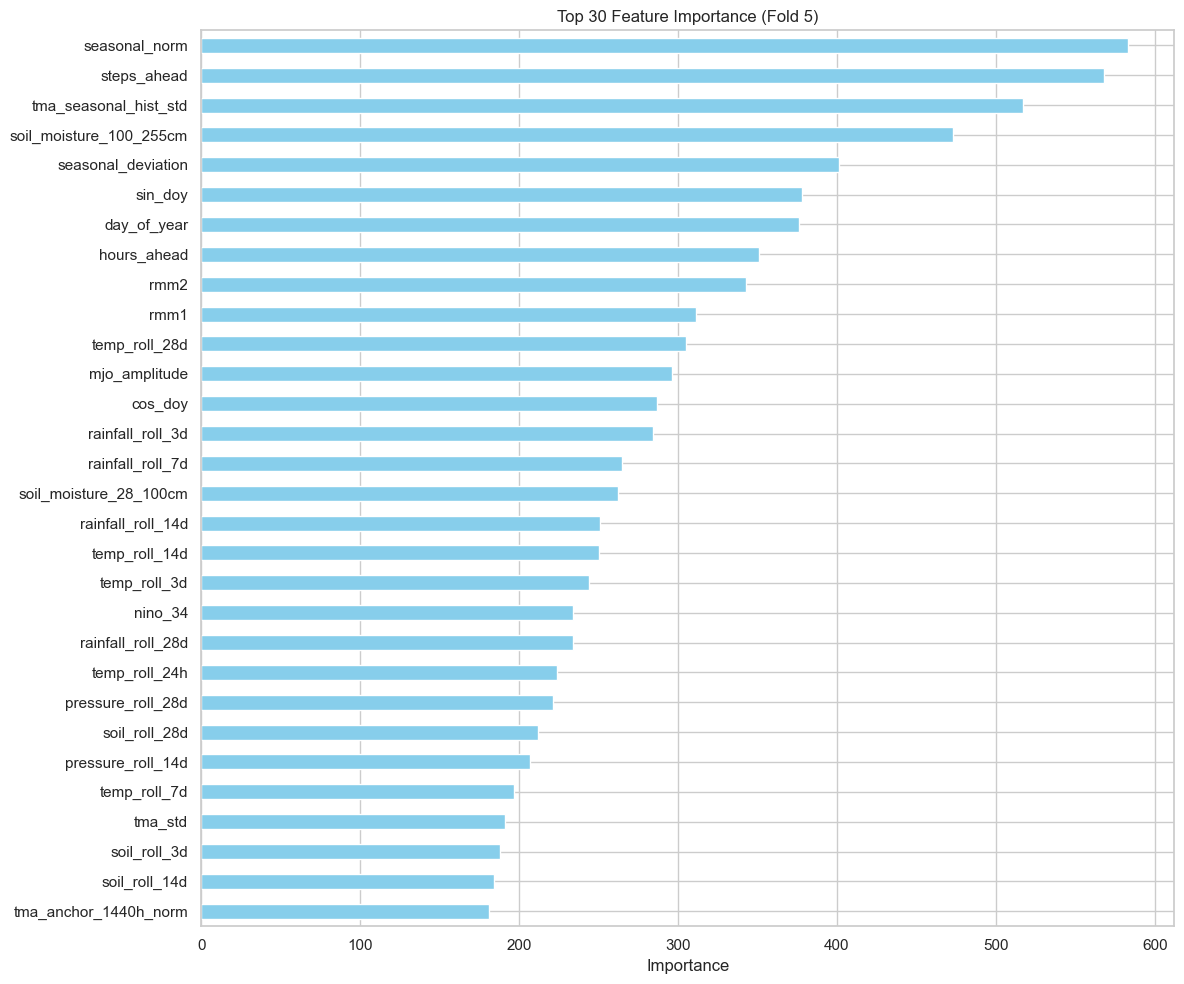

Top 15 features:
seasonal_norm              583
steps_ahead                568
tma_seasonal_hist_std      517
soil_moisture_100_255cm    473
seasonal_deviation         401
sin_doy                    378
day_of_year                376
hours_ahead                351
rmm2                       343
rmm1                       311
temp_roll_28d              305
mjo_amplitude              296
cos_doy                    287
rainfall_roll_3d           284
rainfall_roll_7d           265


In [19]:
# Feature importance dari model terakhir
fi = pd.Series(best_models[-1].feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(12,10))
fi.head(30).plot.barh(color='skyblue')
plt.title('Top 30 Feature Importance (Fold 5)')
plt.xlabel('Importance'); plt.gca().invert_yaxis()
plt.tight_layout(); plt.show()
print('Top 15 features:')
print(fi.head(15).to_string())

## 10. Submisi

In [20]:
test_mean = test_data['tma_mean'].values
test_std  = test_data['tma_std'].values
final_tma = (test_preds * test_std) + test_mean

submission = pd.DataFrame({'id': test_data['id'], 'tma_mdpl': final_tma})
os.makedirs('../submissions', exist_ok=True)
submission.to_csv(OUTPUT_CSV, index=False)

print('Eksperimen 16 selesai!')
print(f'Output: {OUTPUT_CSV}')
print(f'Rentang TMA: {final_tma.min():.2f} - {final_tma.max():.2f}')
print(f'Jumlah prediksi: {len(final_tma):,}')
print(submission.head(10).to_string())

Eksperimen 16 selesai!
Output: ../submissions/submission_13.csv
Rentang TMA: 0.73 - 144.24
Jumlah prediksi: 21,780
                                             id  tma_mdpl
0  2025-09-19 06:00:00 - Arjowinangun - Pacitan    0.8064
1                 2025-09-19 06:00:00 - Serenan   86.0564
2                  2025-09-19 06:00:00 - Sekayu   86.8837
3                 2025-09-19 06:00:00 - Badegan  122.1926
4                   2025-09-19 06:00:00 - Peren   91.2671
5               2025-09-19 06:00:00 - Ngrembang  139.9428
6             2025-09-19 06:00:00 - Bengkelolor    8.4461
7               2025-09-19 06:00:00 - Ngadipiro  143.3844
8            2025-09-19 06:00:00 - Wonogiri Dam  130.0681
9                   2025-09-19 06:00:00 - Napel   34.0430
